# Segmentacija slika pomoću spektralnog klasterovanja

Cilj ove sveske je primena spektralnog klasterovanja (implementiranog u `src/spectral.py`) na problem segmentacije slika.

Pošto direktna primena algoritma na sve piksele slike nije računski izvodljiva (matrica sličnosti bi imala $n^2 \times n^2$ elemenata za sliku sa $n^2$ piksela), slika se prvo deli na **superpiksele** pomoću SLIC algoritma, a graf se zatim gradi nad njima umesto nad pojedinačnim pikselima.

## Pregled parametara

Pre nego što pređemo na analizu, ovde je kratak pregled svih parametara koji se koriste u 
pipeline-u i koji će biti sistematski testirani u narednim eksperimentima.

### SLIC (superpikseli)

| Parametar | Opis |
|---|---|
| `n_segments` | Željeni broj superpiksela na koje se slika deli. Veće vrednosti daju sitnije, brojnije superpiksele — bitno za osetljivost na male objekte na slici. |
| `compactness` | Kontroliše oblik superpiksela: veće vrednosti daju kompaktnije, pravilnije regione, manje vrednosti čine da superpikseli više prate prirodne ivice boja. |

### Karakteristike superpiksela (`compute_superpixel_features`)

Za svaki superpiksel se računaju dve karakteristike:
- **Boja** — prosečna RGB vrednost piksela unutar superpiksela
- **Pozicija** — centroid (prosečna row/col koordinata) superpiksela

### Matrica sličnosti (`build_image_similarity_matrix`)

| Parametar | Opis |
|---|---|
| `sigma_color` | Kontroliše koliko strogo se poštuje sličnost u boji — manje vrednosti favorizuju razlikovanje i suptilnih razlika u boji, veće vrednosti čine da sličnost u boji ima manji uticaj. |
| `sigma_position` | Kontroliše koliko strogo se poštuje prostorna blizina — manje vrednosti razdvajaju čak i vizuelno slične regione ako su prostorno udaljeni, veće vrednosti čine da prostorna udaljenost ima manji uticaj. |

### Spektralno klasterovanje (`spectral_clustering_from_similarity`)

| Parametar | Opis |
|---|---|
| `k` | Broj klastera (segmenata) na koje se slika deli. Direktno određuje granularnost segmentacije. |
| `normalized` | Da li se koristi normalizovani Laplasijan ($L_{sym}$) ili nenormalizovani ($L$). U svim eksperimentima u ovoj svesci koristi se normalizovana varijanta (`normalized=True`), koja je standard u literaturi (Ng-Jordan-Weiss). |

U narednim eksperimentima, jedan od ovih parametara se sistematski menja dok su ostali fiksirani na razumne podrazumevane vrednosti (npr. `n_segments=200`, `sigma_color=20`, `sigma_position=50`, `compactness=10`), kako bi se izolovao uticaj svakog pojedinačnog parametra na rezultat segmentacije.

## Pregled skupa podataka

Pre analize, dajemo kratak pregled slika korišćenih u ovoj svesci — korišćeno je pet slika, namerno 
odabranih da pokriju različite tipove vizuelne strukture (jednostavan kontrast, repetitivna 
tekstura, više objekata različite veličine, objekat sličan pozadini po boji).

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.segmentation import slic, mark_boundaries

from image_utils import (
    compute_superpixel_features,
    build_image_similarity_matrix
)
from spectral import spectral_clustering_from_similarity
from visualization import run_segmentation_grid, analyze_image

Ukupan broj slika: 5

apple.jfif: 2047x2048 px, 3 kanala
balloons.jfif: 750x1334 px, 3 kanala
fields.jfif: 1857x2048 px, 3 kanala
parrot.jfif: 2048x1537 px, 3 kanala
yellow_lilly.jpg: 4032x3024 px, 3 kanala


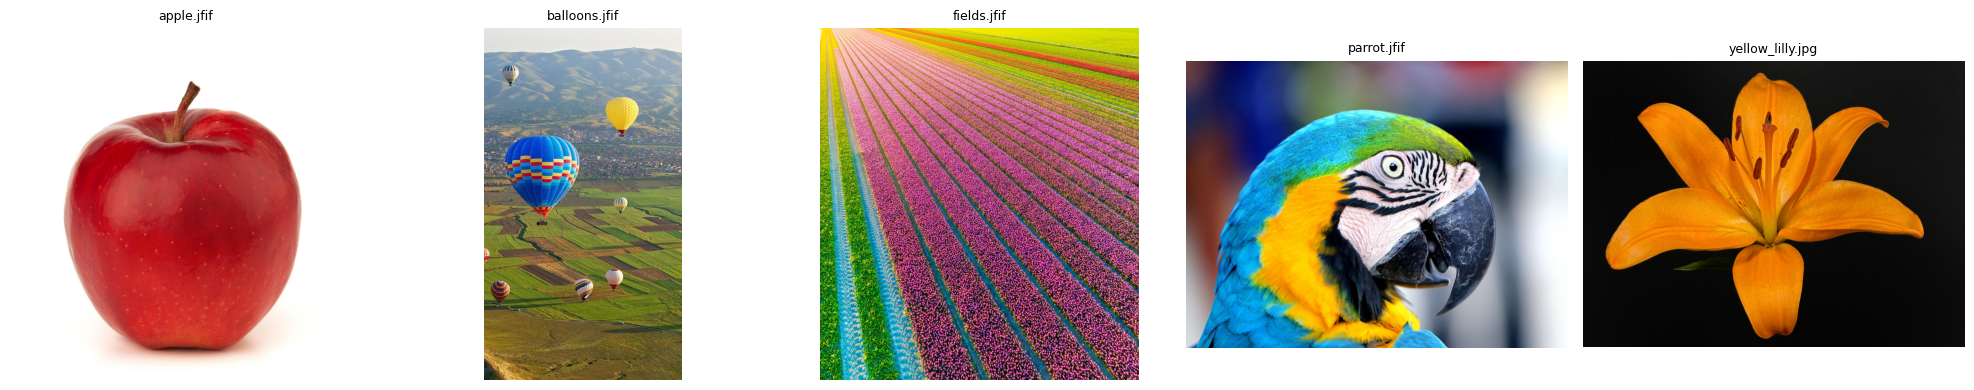

In [2]:
import os

image_dir = '../data/sample_images'
image_files = sorted(f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.jfif', '.png')))

print(f"Ukupan broj slika: {len(image_files)}\n")

fig, axes = plt.subplots(1, len(image_files), figsize=(4 * len(image_files), 4))

for ax, fname in zip(axes, image_files):
    img = io.imread(os.path.join(image_dir, fname))
    print(f"{fname}: {img.shape[1]}x{img.shape[0]} px, {img.shape[2]} kanala")
    ax.imshow(img)
    ax.set_title(fname, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

**Napomena:** Pošto zadatak nije klasifikacija sa unapred definisanim klasama, tradicionalni pojam 
balansiranosti ovde se ne primenjuje. Umesto toga, raznovrsnost skupa se ogleda u razlici u vizuelnoj strukturi slika (kontrast, tekstura, broj i veličina objekata) — svaka slika je odabrana da testira drugačiji aspekt ponašanja algoritma, kao što je detaljno pokazano u analizama 
koje slede.

## 1. Analiza slika

Kao prvi test primer koristimo fotografiju cveta na uniformnoj crnoj pozadini — jednostavna, kontrastna struktura, pogodna za detaljnu proveru celog pipeline-a. Ista logika primenjuje se na četiri dodatne slike, radi provere da pristup konzistentno radi na različitim vizuelnim strukturama (pejzaž, objekat na stolu, izolovan predmet, ptica sa teksturiranim perjem).

### 1.1 Cvet na uniformnoj pozadini

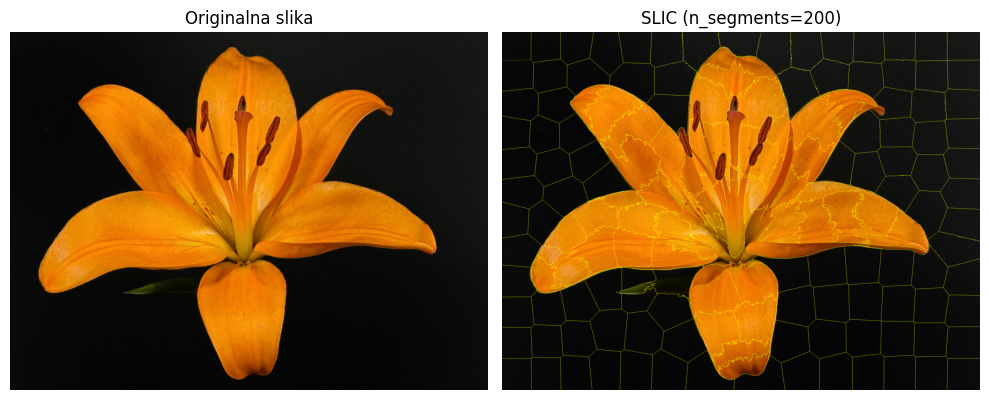

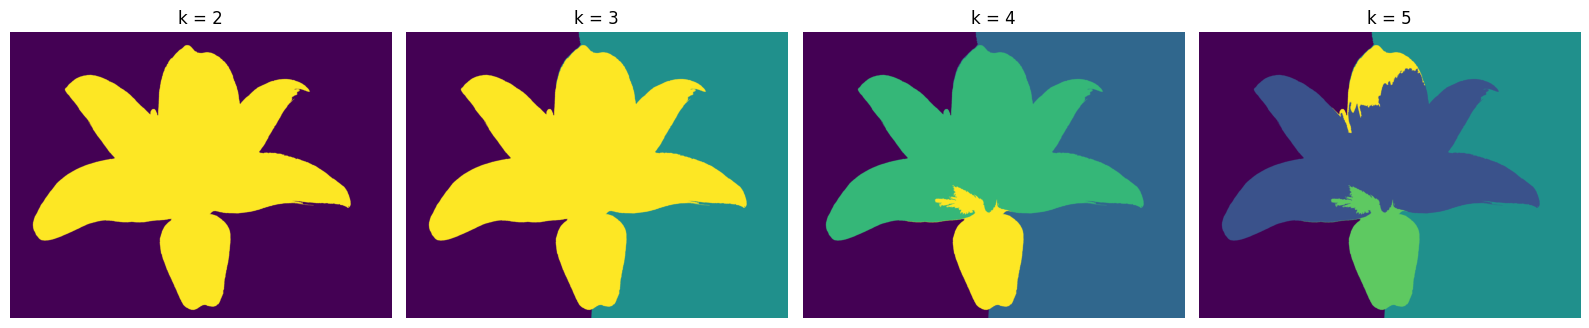

In [3]:
image, segments, colors, positions = analyze_image('../data/sample_images/yellow_lilly.jpg')

**Zapažanje o k-gridu:** Sa porastom $k$, algoritam počinje da deli cvet na više manjih regiona (npr. po pojedinačnim laticama ili nijansama boje), umesto da ga tretira kao jedan segment. Vrednost $k=2$ ili $k=3$ daje najsmisleniju segmentaciju za ovu sliku.

### 1.1.1 Uticaj prostornog parametra ($\sigma_{position}$)

Pored broja klastera, ispitujemo i uticaj $\sigma_{position}$, koji kontroliše koliko strogo se poštuje prostorna blizina prilikom određivanja sličnosti dva superpiksela. Testiramo uz fiksiran $k=4$.

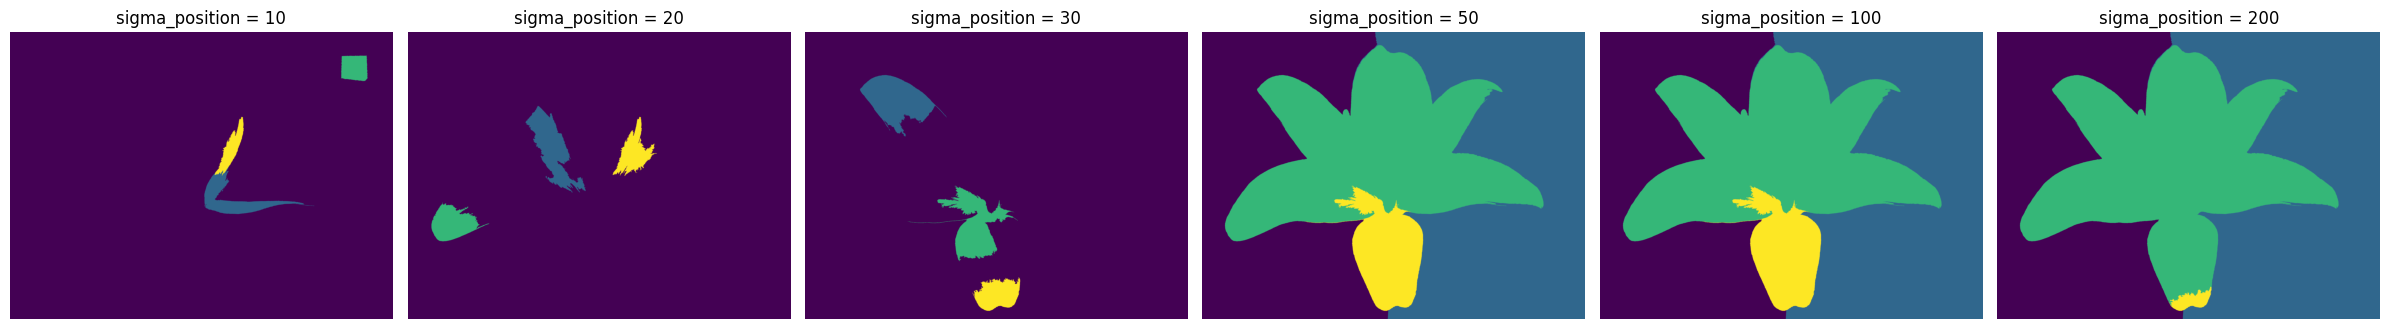

In [4]:
run_segmentation_grid(segments, colors, positions,
                       param_name='sigma_position', param_values=[10,20,30,50,100,200], fixed_k=4)

**Zapažanje:** Za manje vrednosti $\sigma_{position}$, algoritam je osetljiviji na prostornu udaljenost, pa se čak i regioni slične boje mogu razdvojiti ako su prostorno udaljeni. Za veće vrednosti, prostorna komponenta gubi na značaju, i sličnost postaje sve više određena samo bojom.

### 1.2 Fields

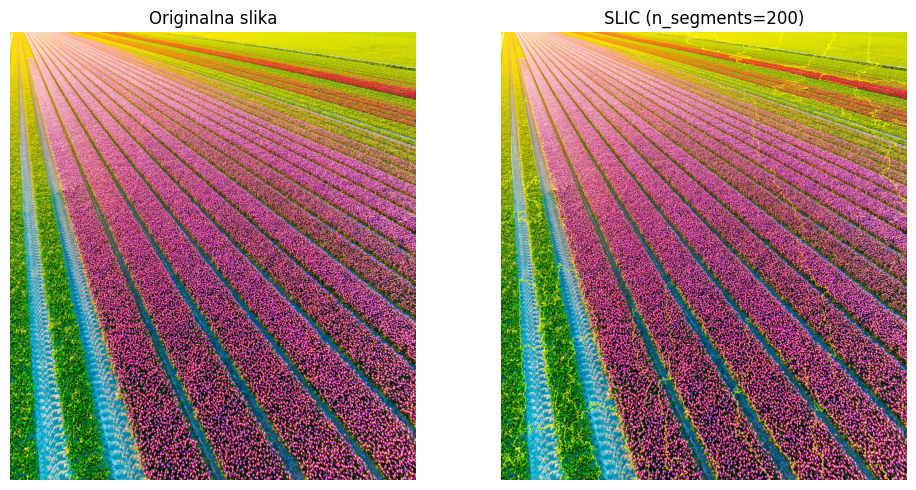

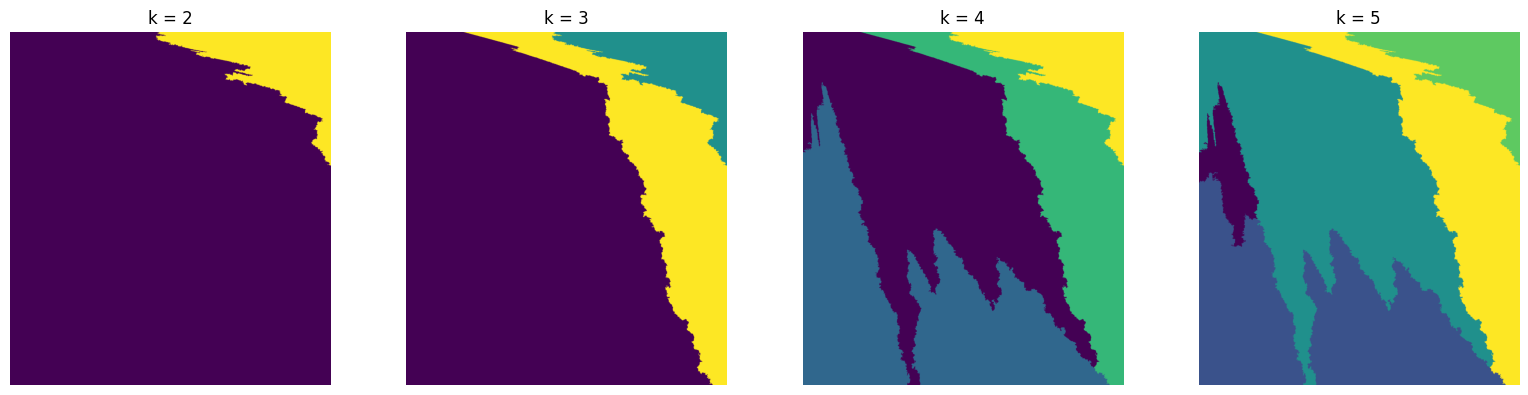

In [5]:
image_2, segments_2, colors_2, positions_2 = analyze_image('../data/sample_images/fields.jfif')

### 1.2.1 Uticaj prostornog parametra ($\sigma_{position}$)

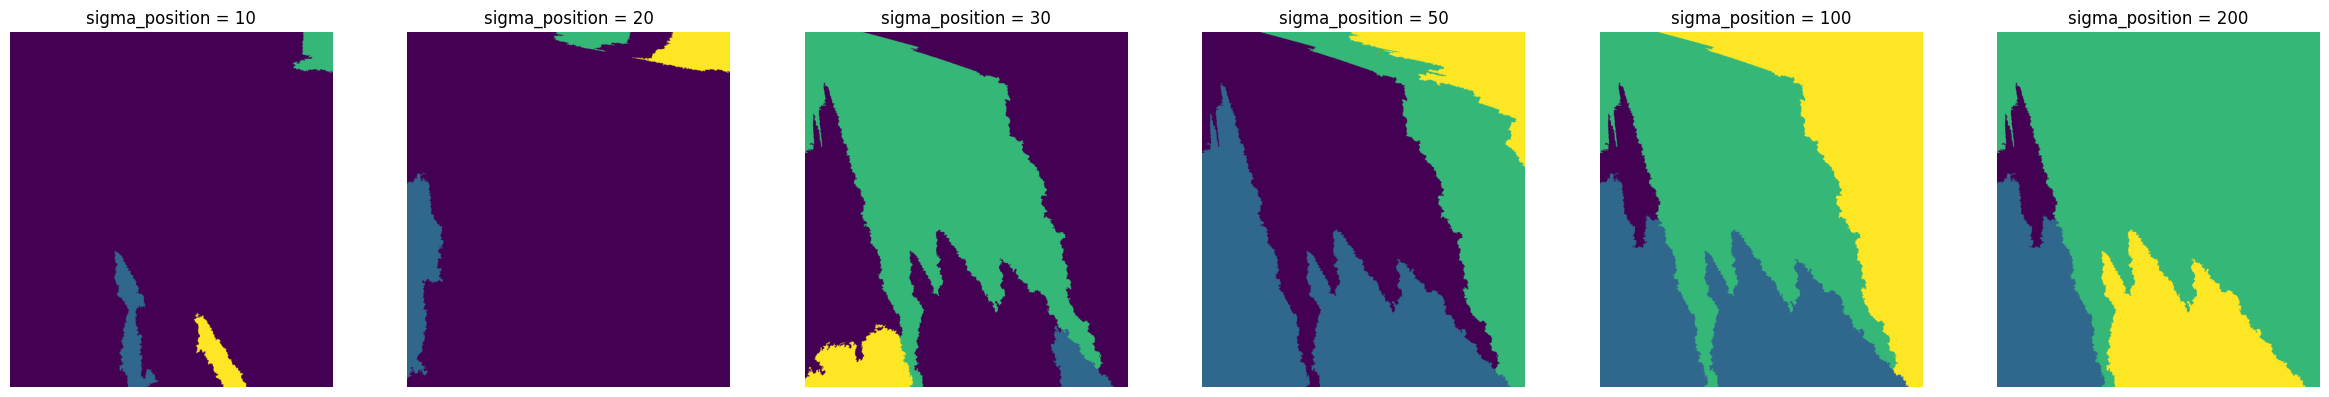

In [6]:
run_segmentation_grid(segments_2, colors_2, positions_2,
                       param_name='sigma_position', param_values=[10,20,30,50,100,200], fixed_k=4)

### 1.2.1 Uticaj parametra boje ($\sigma_{color}$)

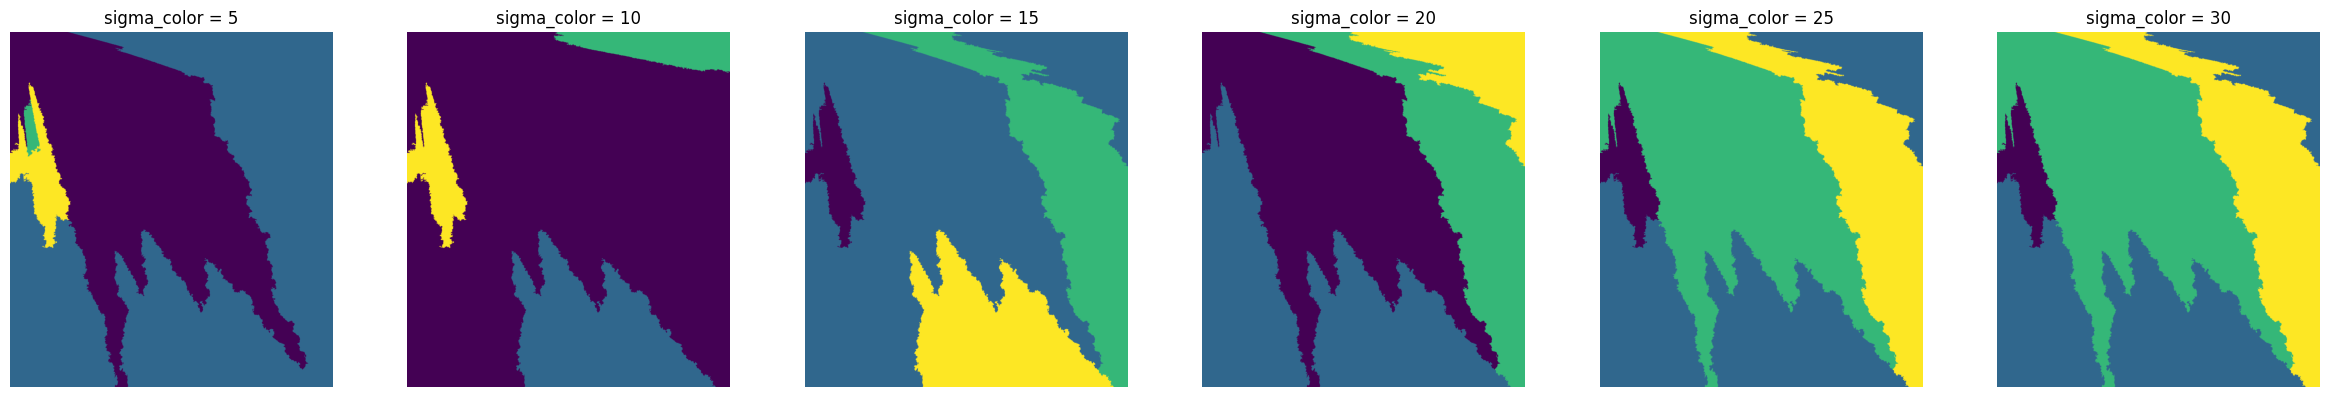

In [7]:
run_segmentation_grid(segments_2, colors_2, positions_2,
                       param_name='sigma_color', param_values=[5,10,15,20,25,30], fixed_k=4)

**Zapažanje:** Kod oba parametra primećuje se sličan trend. Pri veoma malim vrednostima algoritam je previše strog, pa izdvaja samo male lokalne oblasti, dok ostatak slike ostaje u jednom klasteru. Sa povećanjem vrednosti parametara dobija se stabilnija podela slike. Kod $\sigma_{position}$ ovaj obrazac se jasno uočava od vrednosti 30, dok je kod $\sigma_{color}$ izražen od približno 15. Nakon toga se rezultat, u ispitivanom opsegu vrednosti, uglavnom ne menja značajno. Na ovoj slici algoritam pre svega izdvaja veće, prostorno povezane oblasti koje odgovaraju strukturi paralelnih redova cveća, dok ne uspeva da pojedinačne redove izdvoji kao zasebne klastere. To pokazuje da kombinacija boje i prostorne pozicije daje stabilnu segmentaciju većih regiona, ali nije dovoljna za dobro razlikovanje struktura koje imaju sličnu boju i ponavljaju se kroz sliku.

### 1.3 Apple

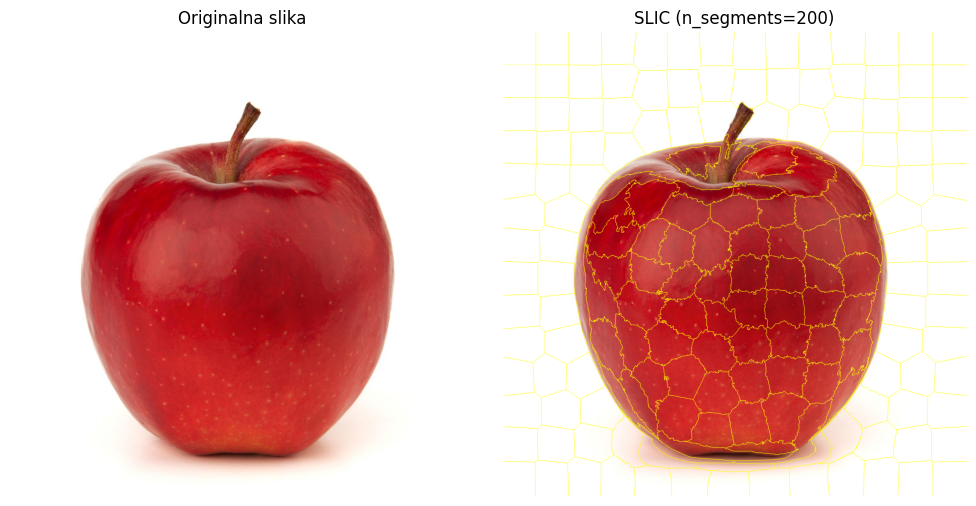

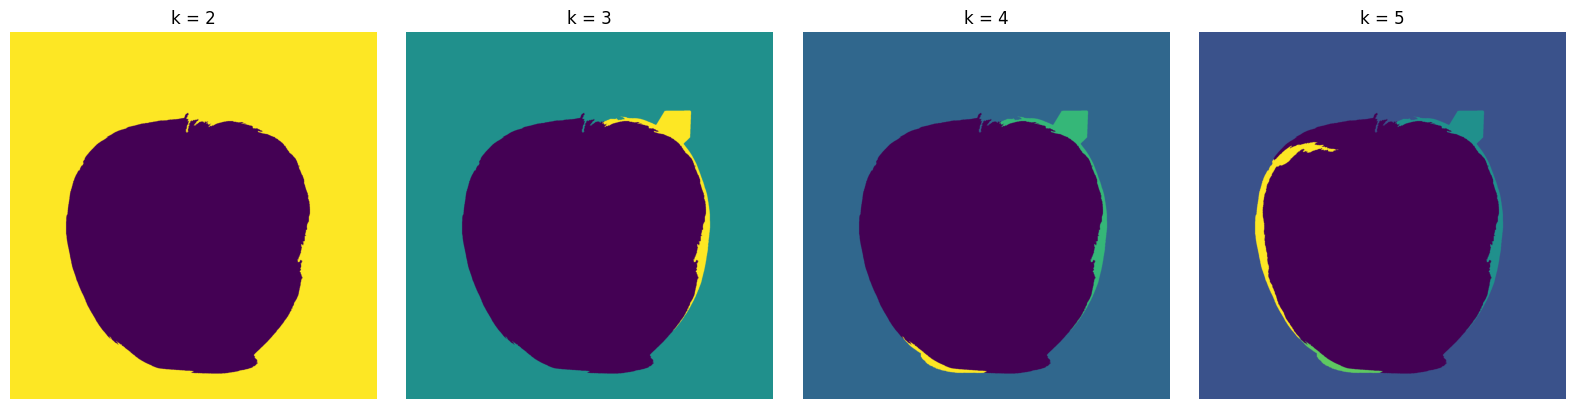

In [8]:
_ = analyze_image('../data/sample_images/apple.jfif')

**Zapažanje:** Za razliku od slike sa poljima, ovde postoji jasan, dominantan kontrast u boji 
između jabuke i pozadine, pa segmentacija ostaje stabilna i tačna za sve testirane 
vrednosti k — jabuka je dosledno izdvojena kao jedan kompaktan segment. Sa porastom k, algoritam 
dodatno izdvaja malu oblast oko drške jabuke, gde se lokalna boja (tamnosmeđa drška naspram 
svetlije pozadine) dovoljno razlikuje da formira zaseban segment. Ovaj primer potvrđuje da 
prisustvo jasnog globalnog kontrasta u boji dovodi do stabilne, predvidljive segmentacije — 
za razliku od slika sa ponavljajućom teksturom bez dominantne boje, prikazane u prethodnom primeru.

### 1.4 Balloon

### 1.4.1 Uticaj parametra $k$

U narednom primeru, testiramo više različitih vrednosti parametra k, kako bismo videli da li se segmentacija popravlja njegovim porastom.

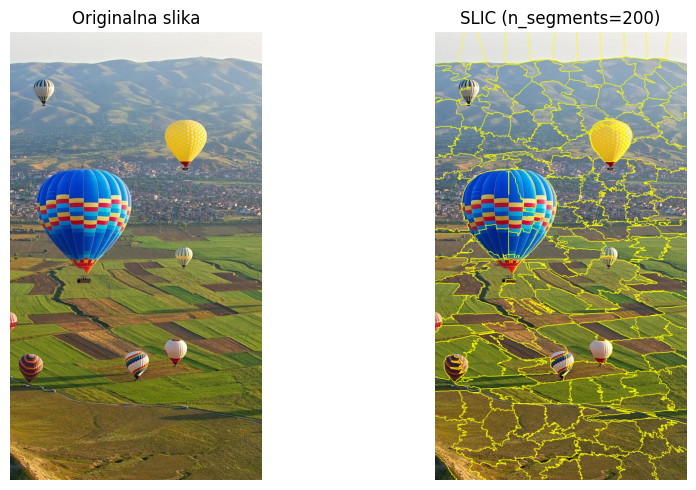

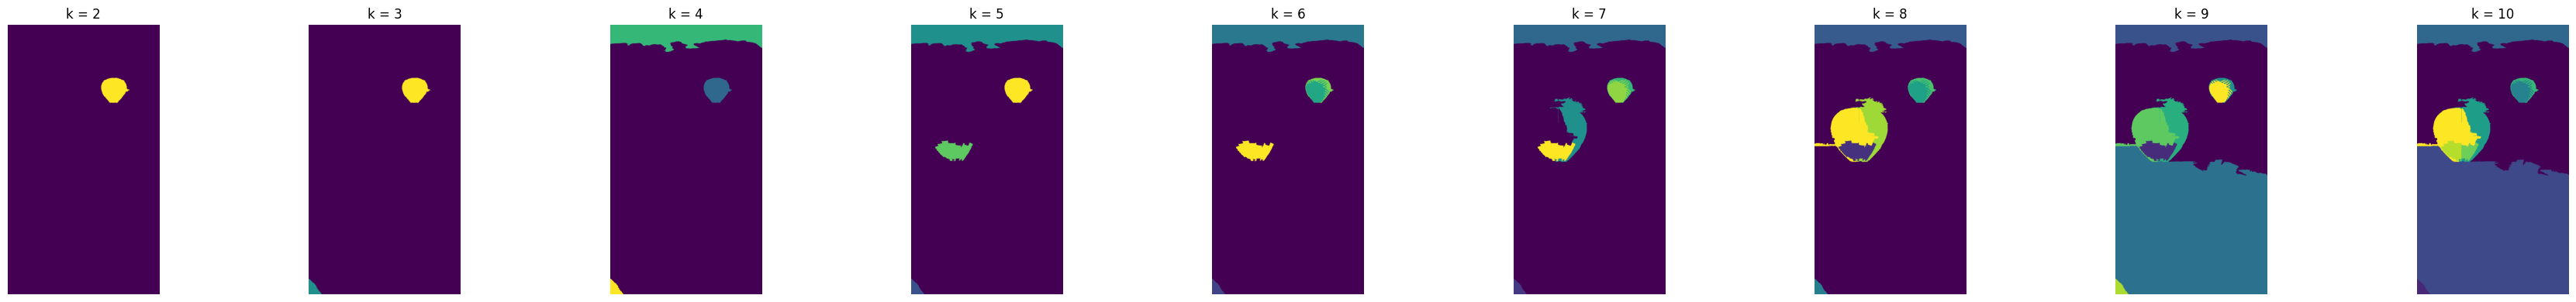

In [9]:
_ = analyze_image('../data/sample_images/balloons.jfif', n_segments=200, k_values=[2, 3, 4, 5, 6, 7, 8, 9, 10])

### 1.4.2 Uticaj parametra $n\_segments$

Takođe ćemo testirati i različite vrednosti parametra n_segments, koji utiče na granularnost superpiksela na slici.

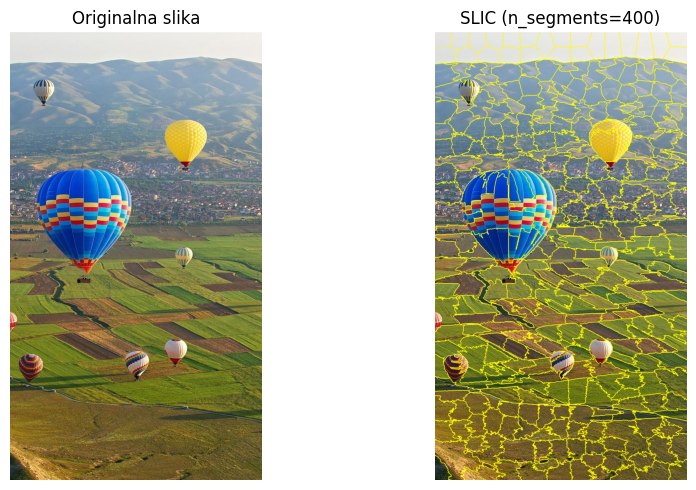

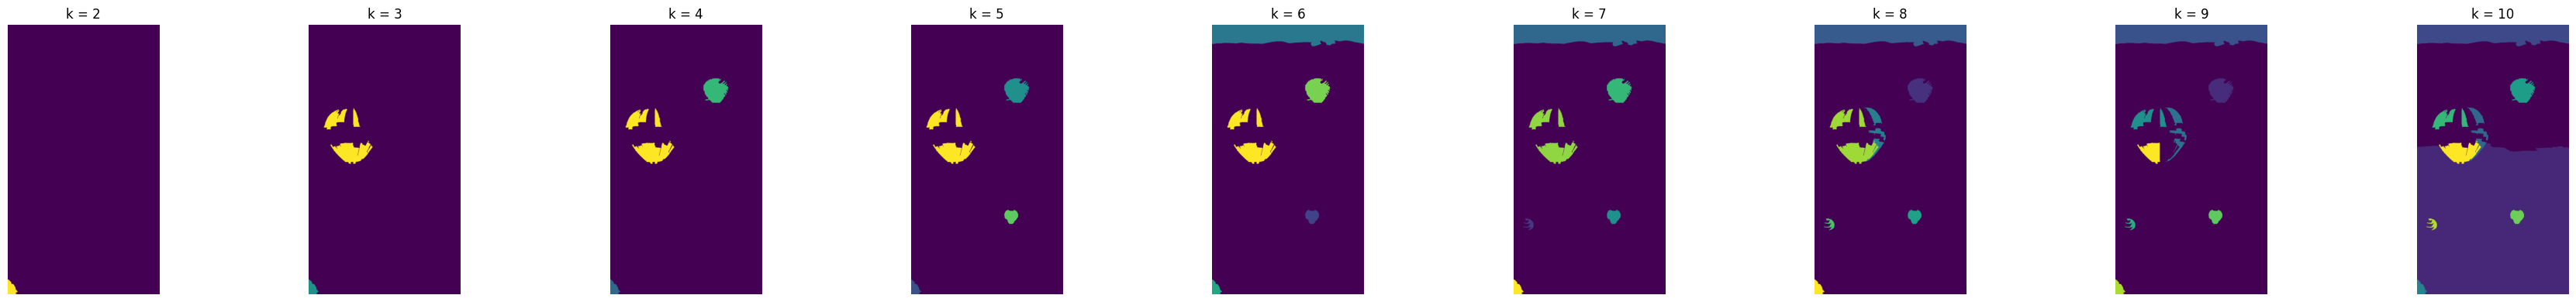

In [10]:
_ = analyze_image('../data/sample_images/balloons.jfif', n_segments=400, k_values=[2, 3, 4, 5, 6, 7, 8, 9, 10])

**Zapažanje:** Sa $n\_segments=200$, pri malim vrednostima $k$ (2 i 3) algoritam izdvaja samo najizraženiji, žuti balon, dok se sa povećanjem broja klastera postepeno izdvajaju i manji objekti u pozadini. Veliki plavi balon se kao zaseban region jasnije izdvaja tek pri većim vrednostima $k$, što se može objasniti njegovim manjim kontrastom u odnosu na okolinu. Sličan obrazac se uočava i za $n\_segments=400$. Veći broj superpiksela daje finiju reprezentaciju slike i omogućava brže izdvajanje najizraženijeg, žutog balona, ali ne rešava problem objekata koji su po boji slični pozadini. Rezultati pokazuju da na uspešnost segmentacije utiču, kako veličina i prostorna reprezentacija objekta, tako i njegov kontrast u odnosu na okolinu. Objekti sa izraženijom razlikom u boji izdvajaju se već pri manjim vrednostima $k$, dok je za objekte koji su sličniji pozadini potrebna detaljnija podela na klastere.

### 1.5 Parrot

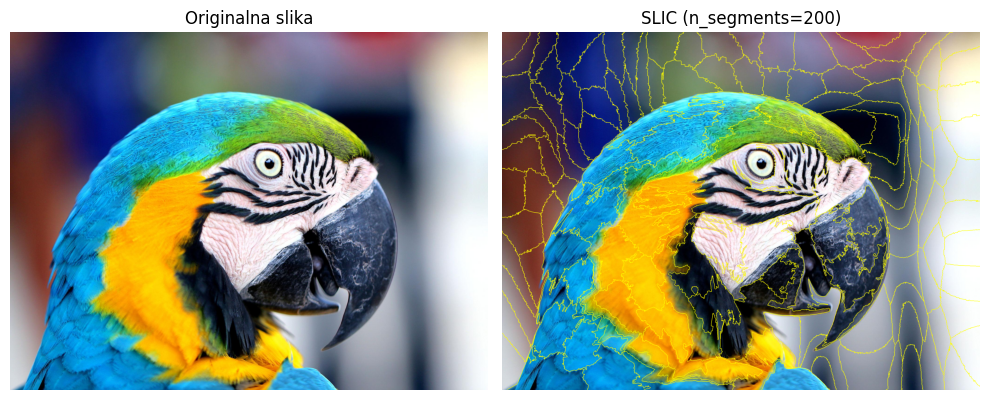

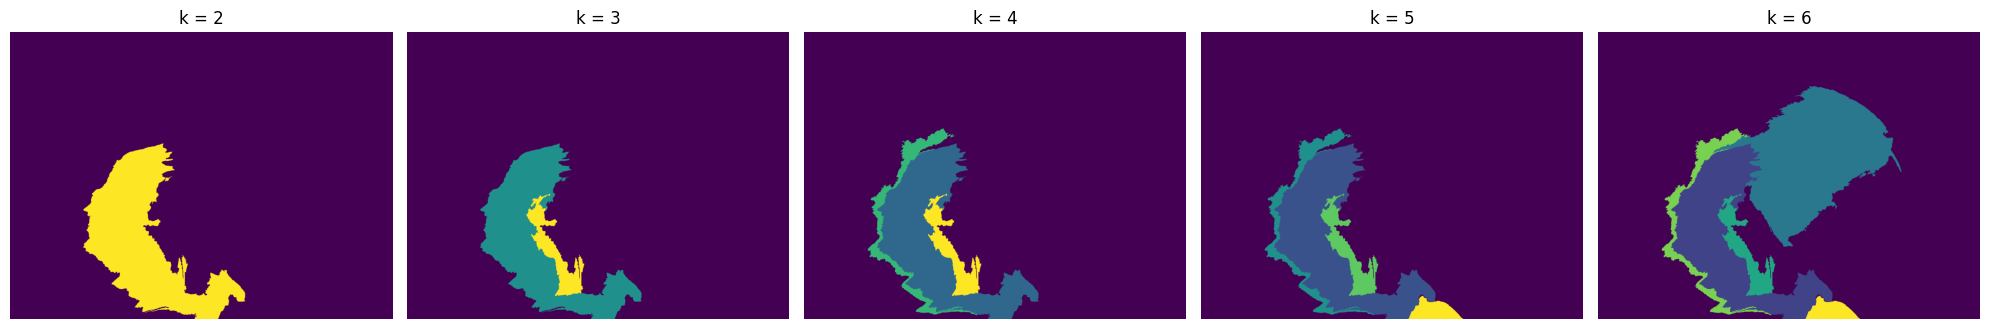

In [11]:
image_4, segments_4, colors_4, positions_4 = analyze_image('../data/sample_images/parrot.jfif',  k_values=[2, 3, 4, 5, 6])

### 1.5.1 Uticaj parametra pozicije ($\sigma_{position}$)

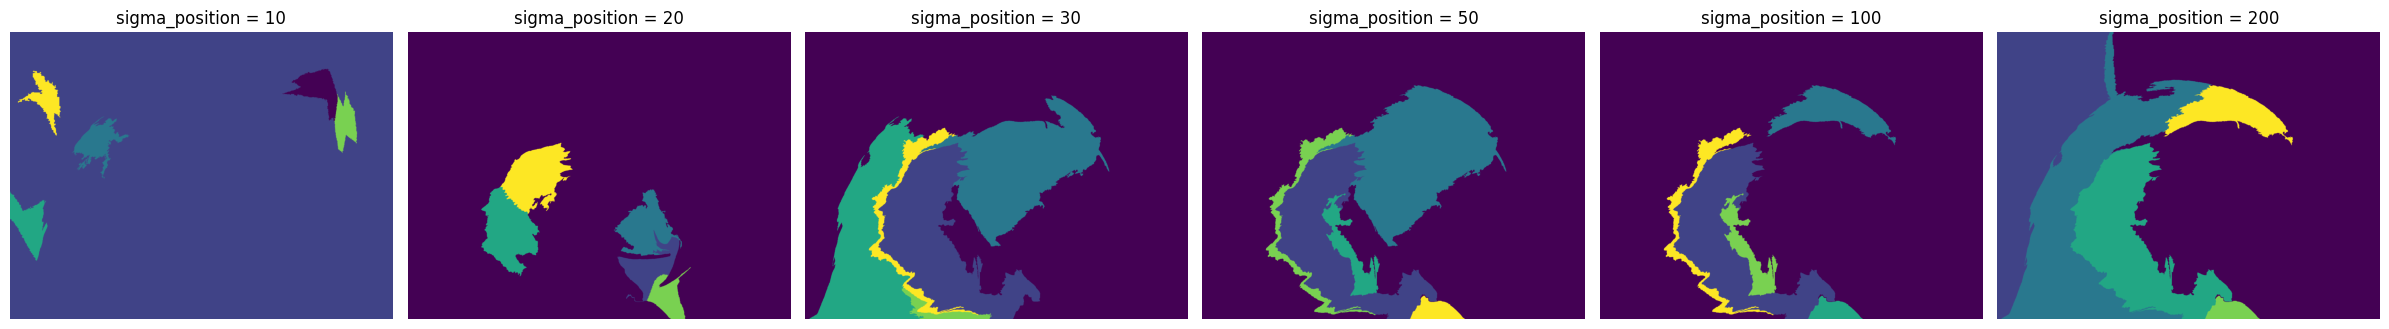

In [12]:
run_segmentation_grid(segments_4, colors_4, positions_4,
                       param_name='sigma_position', param_values=[10,20,30,50,100,200], fixed_k=6)

### 1.5.2 Uticaj parametra boje ($\sigma_{color}$)

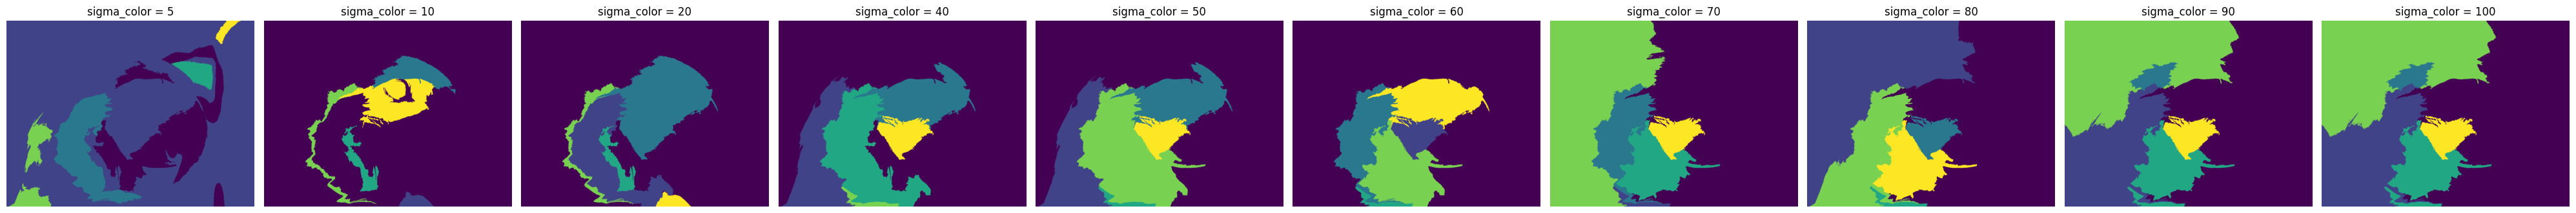

In [13]:
run_segmentation_grid(segments_4, colors_4, positions_4,
                       param_name='sigma_color', param_values=[5,10,20,40,50,60,70,80,90,100], fixed_k=6)

**Zapažanje:** Ni variranje parametra k, kao ni sigma_position i sigma_color ne 
uspevaju da izdvoje u potpunosti siluetu papagaja — granice klastera delimično prolaze kroz telo ptice, 
spajajući delove perja sa pozadinom, bez obzira na testiranu kombinaciju parametara (najtačnije razdvajanje se postiže parametrom sigma_position = 200, gde se algoritam fokusira primarno na boju). Ovo ukazuje da problem nije u izboru parametara, već u reprezentaciji: prosečna boja plavog perja i zamućene, plavičaste pozadine je suviše slična, dok razlika koju ljudsko oko uočava (tekstura, oštrina 
fokusa) nije deo trenutne reprezentacije superpiksela. To predstavlja jasnu granicu pristupa zasnovanog isključivo na boji i poziciji.

## Zaključak

- Kombinacija SLIC superpiksela i spektralnog klasterovanja omogućava segmentaciju slika u 
  razumnom vremenu, zaobilazeći problem velike matrice sličnosti koja bi nastala radom 
  direktno nad pikselima.
- Broj klastera k direktno određuje granularnost segmentacije — manje vrednosti daju grublju, 
  veće finiju podelu.
- Parametri σ_position i σ_color kontrolišu koliko strogo se poštuje prostorna blizina, odnosno 
  sličnost u boji, prilikom određivanja da li su dva superpiksela povezana. Njihov uticaj je 
  posebno izražen kod slika sa vizuelno sličnim, ali prostorno razdvojenim regionima (primer polja cveća), 
  dok kod slika gde je boja objekta bliska boji pozadine (primer papagaja), variranje ni jednog ni drugog 
  parametra ne uspeva da razdvoji objekat od pozadine — što ukazuje da ograničenje u tom slučaju 
  nije parametarsko, već proizlazi iz same reprezentacije (boja + pozicija), kojoj nedostaje 
  informacija o teksturi.
- Testiranje na pet različitih slika pokazuje da pristup najbolje radi kada postoji jasan, 
  globalno dosledan kontrast u boji između objekta i pozadine (primer slika sa cvetom i jabukom) — u tim 
  slučajevima je segmentacija stabilna čak i uz varijacije parametara. Pristup slabije radi u 
  tri tipa situacija:
  1. **Repetitivna tekstura bez globalne razlike u boji** (primer polja cveća) — algoritam 
     počinje da deli sliku po poziciji umesto po sadržaju.
  2. **Više objekata različite prostorne veličine** (primer balona) — mali, udaljeni objekti se 
     gube u dominantnoj pozadini jer zauzimaju premalo superpiksela da bi značajno uticali na 
     globalnu strukturu grafa.
  3. **Nedovoljna razlika u boji između objekta i pozadine** (primer papagaja) — ni sistematsko 
     variranje σ_color ni σ_position ne popravlja segmentaciju kada su boje objekta i pozadine 
     suviše slične, uprkos vizuelnoj razlici vidljivoj kroz teksturu ili oštrinu fokusa.

**Dalji rad:** kvantitativna evaluacija na skupu BSDS500, koji omogućava poređenje sa 
ground-truth segmentacijama, kao i poređenje sa baseline metodom (K-means bez grafovske strukture).